In [233]:
import numpy as np
import torch 
import itertools
import pandas as pd
import matplotlib.pyplot as plt
from anastruct import SystemElements
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt 



In [234]:
df = pd.read_csv('Static Data')

print("Shape (rows,cols):",df.shape)
print("\n Column dtypes:")
print(df.dtypes)
print(df.describe().round(6))
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nDescriptive statistics:")
print(df.describe())


Shape (rows,cols): (125000, 5)

 Column dtypes:
Unnamed: 0      int64
Theta         float64
L_Offset      float64
Area          float64
Max_Force     float64
dtype: object
          Unnamed: 0          Theta       L_Offset           Area  \
count  125000.000000  125000.000000  125000.000000  125000.000000   
mean    62499.500000      25.000000       0.550000       0.006000   
std     36084.536162      11.780349       0.265058       0.002356   
min         0.000000       5.000000       0.100000       0.002000   
25%     31249.750000      14.795918       0.320408       0.003959   
50%     62499.500000      25.000000       0.550000       0.006000   
75%     93749.250000      35.204082       0.779592       0.008041   
max    124999.000000      45.000000       1.000000       0.010000   

           Max_Force  
count  125000.000000  
mean     1226.606850  
std      1281.857644  
min        29.131718  
25%       426.727530  
50%       825.065215  
75%      1518.183510  
max     12636.934117  

In [235]:
print(df.describe().round(6))

          Unnamed: 0          Theta       L_Offset           Area  \
count  125000.000000  125000.000000  125000.000000  125000.000000   
mean    62499.500000      25.000000       0.550000       0.006000   
std     36084.536162      11.780349       0.265058       0.002356   
min         0.000000       5.000000       0.100000       0.002000   
25%     31249.750000      14.795918       0.320408       0.003959   
50%     62499.500000      25.000000       0.550000       0.006000   
75%     93749.250000      35.204082       0.779592       0.008041   
max    124999.000000      45.000000       1.000000       0.010000   

           Max_Force  
count  125000.000000  
mean     1226.606850  
std      1281.857644  
min        29.131718  
25%       426.727530  
50%       825.065215  
75%      1518.183510  
max     12636.934117  


In [236]:
df = df.drop(columns=['Unnamed: 0']) 

In [237]:
FEATURE_COLS = ['Theta', 'L_Offset', 'Area']
TARGET_COL   = 'Max_Force'

In [238]:
x = torch.tensor(df[FEATURE_COLS].values, dtype=torch.float32)
y = torch.tensor(df[TARGET_COL].values, dtype=torch.float32)

# Splice the data set so there is no order to the data.

#we randomly slice the data set.
torch.manual_seed(30)
n = len(x)
indices = torch.randperm(n)
n_train = int(0.75*n)
n_val = int(0.15*n)
n_test=n-n_train-n_val

#create training, validation and testing data sets from the random permutation of the original data set
train_idx = indices[:n_train]
val_idx = indices[n_train : n_train +n_val]
test_idx = indices [n_train + n_val:]

#we identify the target and output
x_train, y_train = x[train_idx],y[train_idx]
x_val,y_val =x[val_idx],y[val_idx]
x_test,y_test=x[test_idx],y[test_idx]



In [239]:
#Normalize data 

#Get Stats Data
x_mean =x_train.mean(dim=0)
x_std = x_train.std(dim=0) #vertical
y_mean =y_train.mean(dim=0)
y_std=y_train.std(dim=0)

norm_stats = {
    'x_mean':x_mean,
    'x_std':x_std,
    'y_mean':y_mean,
    'y_std':y_std,
}

#Normalize Data
x_train = (x_train - x_mean) / x_std
x_val   = (x_val   - x_mean) / x_std
x_test  = (x_test  - x_mean) / x_std

y_train = (y_train - y_mean) / y_std
y_val   = (y_val   - y_mean) / y_std
y_test  = (y_test  - y_mean) / y_std


In [240]:
print("\nAfter normalization (train set):")
print(f"  X_train mean : {x_train.mean(dim=0)} " )
print(f"  X_train std  : {x_train.std(dim=0)}  " )
print(f"  y_train mean : {y_train.mean():.4f}  ")
print(f"  y_train std  : {y_train.std():.4f}  " )


After normalization (train set):
  X_train mean : tensor([1.2386e-07, 1.8962e-08, 8.4717e-08]) 
  X_train std  : tensor([1., 1., 1.])  
  y_train mean : -0.0000  
  y_train std  : 1.0000  


In [241]:
# Create the PyTorch Data Sets

In [242]:
#Create the dataset in respect to the class 

class StructureDataset(Dataset): #via PyTorch we need to define the number of smaples, and how to retrieve a sample
    def __init__(self,x: torch.Tensor,y:torch.Tensor):
        self.x=x
        self.y=y
    
    def __len__(self):
        return len(self.x)
    
    def __getitem__(self,idx):
        return self.x[idx],self.y[idx]
    
train_DS = StructureDataset(x_train,y_train) #training dataset
val_DS = StructureDataset(x_val,y_val) #validation dataset
test_DS = StructureDataset(x_test,y_test) #testing dataset

#since we are dealing with a large dataset. I will create batching (however for smaller datasets, batching is not necessary)
BATCH_SIZE = 256

#DataLoader is a Pytorch class that allow to iterate through dataset in batches with shuffle 
train_loader = DataLoader(
    train_DS,
    batch_size = BATCH_SIZE,
    shuffle =True,
    num_workers=0 #AI recommended . Zero is safest
)

val_loader =DataLoader(
    val_DS,
    batch_size = BATCH_SIZE,
    shuffle =False,
    num_workers=0 
)

test_loader = DataLoader(
    test_DS,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers=0,
)


In [243]:
# Hyper Parametrization of the Model 
#Requirements 
"""
nn.GELU => this will apply gaussian to smooth curves near zero. This is good for stability in nonlinear models
nn.LayerNorm = > it resecales which allows for better gradient and applies to samples (so no worries about batch)
nn.DropOut => this will set random neurons to zero helping the training by creating redundancy 

testing a expanding and then contracting model. 
"""

'\nnn.GELU => this will apply gaussian to smooth curves near zero. This is good for stability in nonlinear models\nnn.LayerNorm = > it resecales which allows for better gradient and applies to samples (so no worries about batch)\nnn.DropOut => this will set random neurons to zero helping the training by creating redundancy \n\ntesting a expanding and then contracting model. \n'

In [244]:
class Force_Prediction(nn.Module):
    def __init__ (self,input_dim: int=3,dropout: float=0.2): #define my layers  #input_dim => how many input arguments we have, dropout => rate of deactivation of neurons
        super().__init__()

        # Input to First Hidden Layer 
        self.block1 = nn.Sequential(
            nn.Linear(input_dim,64), #64 neurons in the first hidden layer # this is typical. We use power 2 values, and the smallest I found online was 32. But since this specific dataset is medium large , AI recommended 64)
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.block2=nn.Sequential(
            nn.Linear(64,128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        
        self.block3=nn.Sequential(
            nn.Linear(128,256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.block4=nn.Sequential(
            nn.Linear(256,128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.block5=nn.Sequential(
            nn.Linear(128,64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.output_layer = nn.Linear(64,1)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.output_layer(x)   # ← lowercase x
        return x.squeeze(1)


In [245]:
model = Force_Prediction(input_dim=3,dropout=0.0)
print(model)

Force_Prediction(
  (block1): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.0, inplace=False)
  )
  (block2): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.0, inplace=False)
  )
  (block3): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.0, inplace=False)
  )
  (block4): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.0, inplace=False)
  )
  (block5): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True

In [246]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")


Total trainable parameters: 84,097


In [247]:
# Training samples   : 87,500
# Model parameters   : 84,097
# Ratio              : ~1.04 samples per parameter

In [248]:
# training Loops now 

In [249]:
# ensure the mode runs on the CPU computer 

device = torch.device("mps" if torch.backends.mps.is_available()else"cpu") #mps is gpu for macs
model = model.to(device)


In [250]:
criterion =nn.MSELoss() 
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3, #learning rate
    weight_decay =1e-4 #to be adjusted based on what we get
)
# we can use different models based on the feedback of the performance . For this case AdamW decouples the weigth decay from the optimization step which can lead to better performance in some cases.
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode ='min', #loss goes down
    factor =0.5, #reduced by half
    patience =5,#number of epochs (trials) before reducing learning rate if nothing is happening
    min_lr=1e-6
)

num_epochs =100 
patience =15 #stops after 15 epochs if no improvement after 15 consecutive epochs



In [251]:
#Epoch Training 

def train_epoch1(model,loader,optimizer,criterion,device):
    model.train()
    total_loss = 0.0

    for x_batch, y_batch in loader:
        optimizer.zero_grad() #reset to zero the gradient from the previous batch
        x_batch, y_batch = x_batch.to(device),y_batch.to(device)
        prediction = model(x_batch) #prediction aka forward path
        loss =criterion(prediction,y_batch) #how wrong predictions
        loss.backward() 
        optimizer.step() #necessary for the Adam model 
        total_loss += loss.item() * len(x_batch)
    return total_loss/len(loader.dataset)

@torch.no_grad() #dont track gradient since PyTorch builds a computaiton graph in the background,during validation we dont need to track gradient (no update to the weights)

#validation model 
def epoch_val(model,loader,criterion,device):
    model.eval() #BIG DIFFERENCE ! 
    total_loss=0.0

    for x_batch,y_batch in loader:
        x_batch, y_batch = x_batch.to(device),y_batch.to(device)
        predictions = model(x_batch)
        loss =criterion (predictions,y_batch)
        total_loss += loss.item() * len(x_batch)
        return total_loss/len(loader.dataset)
    




In [252]:
#Parameters 
#We want to keep track. THis is just setting up a "diary" to keep track
train_losses = [] 
val_losses = []
best_val_loss = float('inf')
best_model_stats= None
epochs_no_improve =0




In [253]:
print(f"{'Epoch':>6} | {'Train Loss':>12} | {'Val Loss':>12} | {'LR':>10}")
print("-" * 50)

for epoch in range(1,num_epochs+1):
    train_loss = train_epoch1(model,train_loader,optimizer,criterion,device)
    val_loss = epoch_val(model,val_loader,criterion,device)
    scheduler.step(val_loss) # send to scheduler which will decide if we need to readjust the learning rate
    train_losses.append(train_loss) #diary keeping 
    val_losses.append(val_loss)
    current_lr = optimizer.param_groups[0]['lr'] #this will let me know when the learning rate has been readjusted by adding the current learning rate to said diary 

    #now the conditions 
    if epoch %5 ==0 or epoch ==1:
        print(f"{epoch:>6} | {train_loss:>12.6f} | {val_loss:>12.6f} | {current_lr:>10.2e}")
    if val_loss < best_val_loss:
        # Validation loss improved — save this model state
        best_val_loss    = val_loss
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        # No improvement this epoch
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        print(f"No improvement for {patience} consecutive epochs.")
        break

model.load_state_dict(best_model_state)
print(f"\nBest model restored — Val Loss: {best_val_loss:.6f}")
print(f"Training complete. Total epochs run: {len(train_losses)}")

 Epoch |   Train Loss |     Val Loss |         LR
--------------------------------------------------


     1 |     0.038401 |     0.000041 |   1.00e-03
     5 |     0.000562 |     0.000001 |   1.00e-03
    10 |     0.002062 |     0.000009 |   1.00e-03
    15 |     0.000079 |     0.000000 |   5.00e-04
    20 |     0.000066 |     0.000001 |   5.00e-04
    25 |     0.000026 |     0.000002 |   2.50e-04
    30 |     0.000039 |     0.000000 |   1.25e-04
    35 |     0.000018 |     0.000000 |   1.25e-04
    40 |     0.000003 |     0.000000 |   6.25e-05
    45 |     0.000007 |     0.000000 |   3.13e-05
    50 |     0.000003 |     0.000000 |   3.13e-05
    55 |     0.000001 |     0.000000 |   1.56e-05
    60 |     0.000001 |     0.000000 |   1.56e-05
    65 |     0.000001 |     0.000000 |   7.81e-06
    70 |     0.000001 |     0.000000 |   3.91e-06
    75 |     0.000001 |     0.000000 |   3.91e-06
    80 |     0.000001 |     0.000000 |   3.91e-06
    85 |     0.000001 |     0.000000 |   3.91e-06
    90 |     0.000001 |     0.000000 |   3.91e-06
    95 |     0.000001 |     0.000000 |   3.91e-06


In [254]:
test_loss = epoch_val(model,test_loader,criterion,device)
all_predictions = []
all_actuals = [] 

model.eval()
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch, y_batch = x_batch.to(device),y_batch.to(device)
        y_pred = model(x_batch)
        all_predictions.append(y_pred.cpu())
        all_actuals.append(y_batch.cpu())

all_predictions = torch.cat(all_predictions)
all_actuals = torch.cat(all_actuals)

y_predictions_newtons = (all_predictions*y_std)+y_mean
y_actuals_newtons = (all_actuals*y_std)+y_mean
y_pnp=y_predictions_newtons.numpy()
y_anp=y_actuals_newtons.numpy()

# Error 

mae = np.mean(np.abs(y_pnp-y_anp))
rmse = np.sqrt(np.mean((y_pnp-y_anp)**2))
ss_res =np.sum((y_anp-y_pnp)**2)
ss_tot =np.sum((y_anp-y_anp.mean()**2))
r2 = 1-(ss_res/ss_tot)
max_error =np.max(np.abs(y_pnp-y_anp))


In [255]:
print(f"\n{'='*45}")
print(f"  Error Metrics on Test Set")
print(f"{'='*45}")
print(f"  Features : Theta, L_Offset, Area")
print(f"  Target   : Max_Force")
print(f"  Samples  : {len(y_pnp):,}")
print(f"{'-'*45}")
print(f"  MAE        : {mae:.4f} N")
print(f"  RMSE       : {rmse:.4f} N")
print(f"  R²         : {r2:.6f}")
print(f"  Max Error  : {max_error:.4f} N")
print(f"{'='*45}")
print(f"\n Conclusion:")
print(f"  Model deviation: {mae:.2f} N")
print(f"  Actual Max_Force ranges from {y_anp.min():.2f} N to {y_anp.max():.2f} N")
print(f"  Error as % of range : {(mae / (y_anp.max() - y_anp.min())) * 100:.4f}%")



  Error Metrics on Test Set
  Features : Theta, L_Offset, Area
  Target   : Max_Force
  Samples  : 12,500
---------------------------------------------
  MAE        : 0.6448 N
  RMSE       : 0.8868 N
  R²         : 1.000001
  Max Error  : 11.2119 N

 Conclusion:
  Model deviation: 0.64 N
  Actual Max_Force ranges from 37.69 N to 11811.68 N
  Error as % of range : 0.0055%


In [256]:
# Plotting 

Plot saved: training_report.png


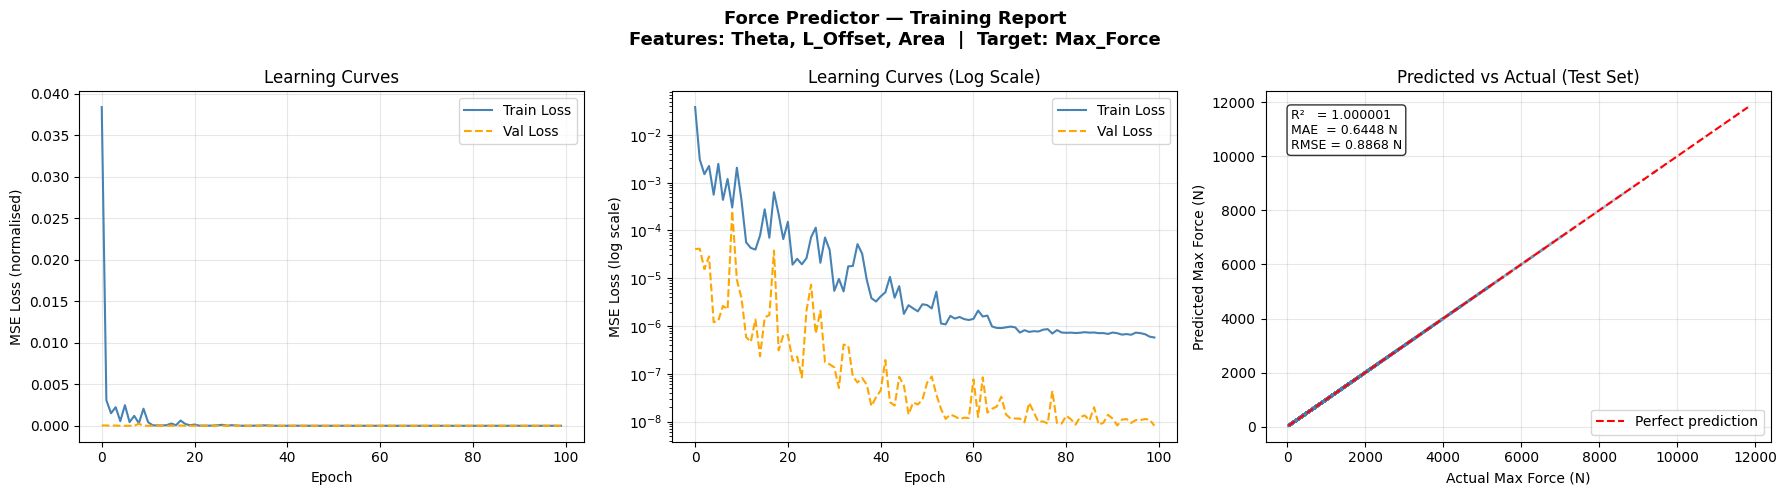

In [257]:


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Force Predictor — Training Report\nFeatures: Theta, L_Offset, Area  |  Target: Max_Force',
             fontsize=13, fontweight='bold')

ax1 = axes[0]
ax1.plot(train_losses, label='Train Loss', linewidth=1.5, color='steelblue')
ax1.plot(val_losses,   label='Val Loss',   linewidth=1.5, color='orange', linestyle='--')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss (normalised)')
ax1.set_title('Learning Curves')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(train_losses, label='Train Loss', linewidth=1.5, color='steelblue')
ax2.plot(val_losses,   label='Val Loss',   linewidth=1.5, color='orange', linestyle='--')
ax2.set_yscale('log')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MSE Loss (log scale)')
ax2.set_title('Learning Curves (Log Scale)')
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3 = axes[2]
ax3.scatter(y_anp, y_pnp, alpha=0.2, s=5, color='steelblue', edgecolors='none')

min_val = y_anp.min()
max_val = y_anp.max()
ax3.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect prediction')

textstr = f'R²   = {r2:.6f}\nMAE  = {mae:.4f} N\nRMSE = {rmse:.4f} N'
ax3.text(0.05, 0.95, textstr, transform=ax3.transAxes, fontsize=9,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax3.set_xlabel('Actual Max Force (N)')
ax3.set_ylabel('Predicted Max Force (N)')
ax3.set_title('Predicted vs Actual (Test Set)')
ax3.legend(loc='lower right')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_report.png', dpi=150, bbox_inches='tight')
print("Plot saved: training_report.png")
plt.show()

In [1]:

# Instead of state_dict, save the object itself
torch.save(Sohoite_model, 'full_model_Sohoite.pt')

NameError: name 'torch' is not defined